# Практическое занятие №4: Полный цикл предобработки данных

## Цель работы


Научиться применять на практике все изученные приёмы подготовки данных: от загрузки «сырого» датасета до получения чистой, структурированной таблицы, готовой к анализу или моделированию.

## Вариант 10: Датасет «Attention» (внимание и время реакции)

Источник: ```sns.load_dataset('attention')```

Описание: Время реакции испытуемых в зависимости от внимания и типа задания.

Задачи:
1. Привести данные к широкому формату: строки – испытуемые, столбцы –
время реакции при разных условиях (подсказка: pivot).
2. Удалить дубликаты.
3. Проверить наличие выбросов во времени реакции (использовать IQR).
4. Заменить выбросы на границы IQR.
5. Построить ящики с усами для разных уровней внимания.

Основные столбцы таблицы:

* subject: Идентификатор участника эксперимента (номер).
* attention: Уровень внимания. divided — разделенное, focused — сфокусированное.

* solutions: Тип или количество решений/задач.
* score: Числовой результат (оценка/балл).

Размер исходных данных:
 (60, 5)


    Unnamed: 0  subject attention  solutions  score
0           0        1   divided          1    2.0
1           1        2   divided          1    3.0
2           2        3   divided          1    3.0
3           3        4   divided          1    5.0
4           4        5   divided          1    4.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  60 non-null     int64  
 1   subject     60 non-null     int64  
 2   attention   60 non-null     object 
 3   solutions   60 non-null     int64  
 4   score       60 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 2.5+ KB

Общая информация о данных:
 None

Проверка пропусков:
 Unnamed: 0    0
subject       0
attention     0
solutions     0
score         0
dtype: int64

Приведенные данные после широкого формата:
         divid

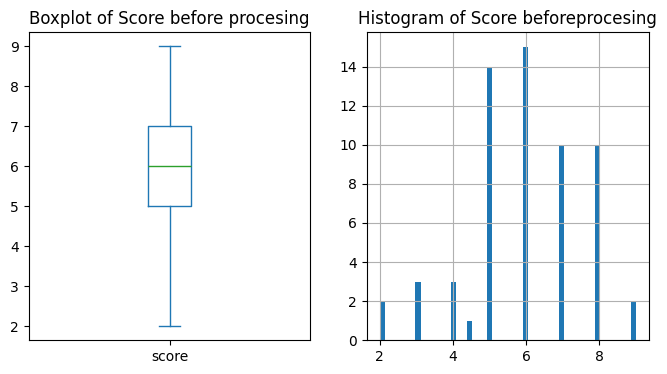

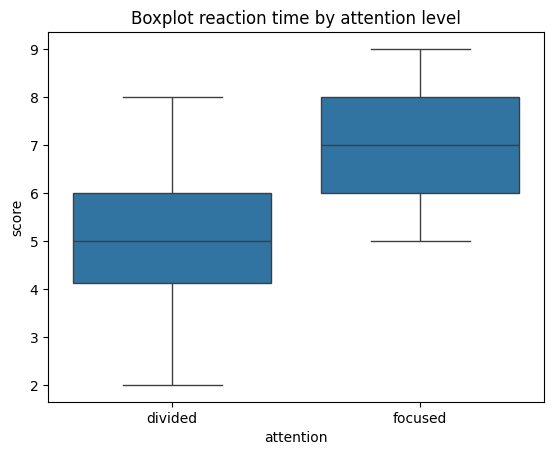


Результат:
         divided_1 divided_2 divided_3 focused_1 focused_2 focused_3  mean_score  max_score
subject                                                                                   
1             2.0       4.0       7.0         -         -         -        4.33        7.0
2             3.0       4.0       5.0         -         -         -        4.00        5.0
3             3.0       5.0       6.0         -         -         -        4.67        6.0
4             5.0       7.0       5.0         -         -         -        5.67        7.0
5             4.0       5.0       8.0         -         -         -        5.67        8.0
6             5.0       5.0       6.0         -         -         -        5.33        6.0
7             5.0       4.5       6.0         -         -         -        5.17        6.0
8             5.0       7.0       8.0         -         -         -        6.67        8.0
9             2.0       3.0       7.0         -         -         -        4.

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = sns.load_dataset('attention')
print("Размер исходных данных:\n", df.shape)

# Первичный осмотр
print('\n\n',df.head())
print('\nОбщая информация о данных:\n', df.info())

# Проверка пропусков
print('\nПроверка пропусков:\n', df.isnull().sum())

# 1. Приведение к широкому формату
df_wide = df.pivot_table(
    index='subject',
    columns=['attention', 'solutions'],
    values='score'
)

# Выравниваем названия столбцов
df_wide.columns = [
    f'{attention}_{solution}'
    for attention, solution in df_wide.columns
]

print('\nПриведенные данные после широкого формата:\n', df_wide.fillna('-'))

# 2. Удаление дубликатов
df.drop_duplicates(inplace=True)

# 3. Обработка выбросов

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
df['score'].plot(kind='box')
plt.title('Boxplot of Score before procesing')
plt.subplot(1,2,2)
df['score'].hist(bins=50)
plt.title('Histogram of Score beforeprocesing')
plt.show()

# Границы выброса
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 4. Замена выбросов на граничные значения
df['score'] = np.where(df['score'] > upper, upper, df['score'])
df['score'] = np.where(df['score'] < lower, lower, df['score'])

# Проверка (не нужна в это примере, выбросов нет)
# plt.figure(figsize=(8,4))
# plt.subplot(1,2,1)
# df['score'].plot(kind='box')
# plt.title('Boxplot of Score after')
# plt.subplot(1,2,2)
# df['score'].hist(bins=50)
# plt.title('Histogram of Score after')
# plt.show()

# Новый признак (согласно критерию оценивания)
df_wide['mean_score'] = df_wide.mean(axis=1).round(2)
df_wide['max_score'] = df_wide.max(axis=1)

# 5. Boxplot (ящик с усами)
sns.boxplot(data=df, x='attention', y='score')
plt.title('Boxplot reaction time by attention level')
plt.show()

pd.set_option('display.expand_frame_repr', False) # pandas не будет переносить столбец при выводе вниз, а оставит рядом с другими столбцами
print('\nРезультат:\n', df_wide.fillna('-'))

# Сохранение
df.to_csv('attention_cleaned.csv', index=False)